<h2>📊 Loading Titanic Dataset</h2>

In this step, we import required libraries and load the dataset into a Pandas DataFrame.

<b>Pandas (pd)</b> is used for data manipulation and analysis.
<b>NumPy (np)</b> is used for numerical operations.

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

df = pd.read_csv('titanic_train.csv')


<h2>🔹 Preview Data</h2>


In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<h2>🧹 Dropping Unnecessary Column</h2>

In this step, we remove the PassengerId column from the dataset.

<h2>📌 Explanation</h2>
PassengerId is just a unique identifier for each passenger.
It does not help in prediction, so we remove it.
inplace=True means the change is applied directly to the original DataFrame.


In [5]:
df.drop(columns=['PassengerId'],inplace=True)

In [6]:
df.shape

(891, 11)

In [7]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [8]:
df['Cabin'].fillna(0,inplace=True)

C:\Users\LENOVO THINKBOOK\AppData\Local\Temp\ipykernel_20652\2056631867.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cabin'].fillna(0,inplace=True)


In [9]:
df['Cabin'].head(10)

0       0
1     C85
2       0
3    C123
4       0
5       0
6     E46
7       0
8       0
9       0
Name: Cabin, dtype: object

In [10]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\LENOVO THINKBOOK\AppData\Local\Temp\ipykernel_20652\1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [11]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    2
dtype: int64

<h2>🧩 Handling Missing Values (Embarked Column)</h2>

In this step, we fill missing values in the Embarked column using the most frequent value

In [12]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='most_frequent')

df['Embarked'] = impute.fit_transform(df[['Embarked']]).ravel()

In [13]:
df[(df['Survived'] == 0) & (df['Sex'] == 'male')].shape[0]

468

In [14]:
df.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,0,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,0,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,0,S
5,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,0,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S
7,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,0,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,0,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,0,C


<h2>🔍 Custom Function for Conditional Counting</h2>

This function is used to count the number of rows based on multiple conditions.

<h2>📌 Explanation</h2>
value1 → value for the Survived column (0 = No, 1 = Yes)
value2 → column name (e.g., 'Sex', 'Pclass')
value3 → value inside that column (e.g., 'male', 1)
(df['Survived'] == value1) → filters survival condition
(df[value2] == value3) → filters another condition
& → combines both conditions
.shape[0] → returns the number of matching rows

In [15]:
def value(value1,value2,value3):

    value_1 = df[(df['Survived'] == value1) & (df[value2] == value3)].shape[0]

    print(value_1)

In [16]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [17]:
value(value1=1,value2='Parch',value3=0)

233


In [18]:
df.value_counts(df['Pclass'])

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [19]:
df.value_counts(df['Sex'])

Sex
male      577
female    314
Name: count, dtype: int64

In [20]:
import seaborn as sns

<h3>📊 Count Plot of Survival</h3>

This plot shows the number of passengers who survived and who did not.

<Axes: xlabel='Survived', ylabel='count'>

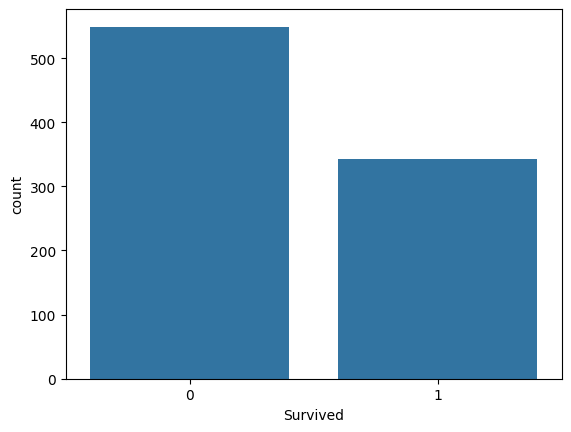

In [21]:
sns.countplot(x='Survived', data=df)

<h3>📊 Passenger Class Distribution</h3>

This plot shows the number of passengers in each class.

<Axes: xlabel='Pclass'>

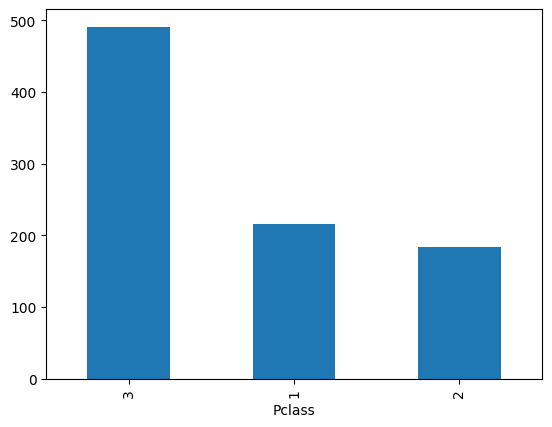

In [22]:
df['Pclass'].value_counts().plot(kind='bar')

<h3>🎟️ Survival by Passenger Class</h3>

This plot shows how survival varies across different passenger classes.

<Axes: xlabel='Pclass', ylabel='count'>

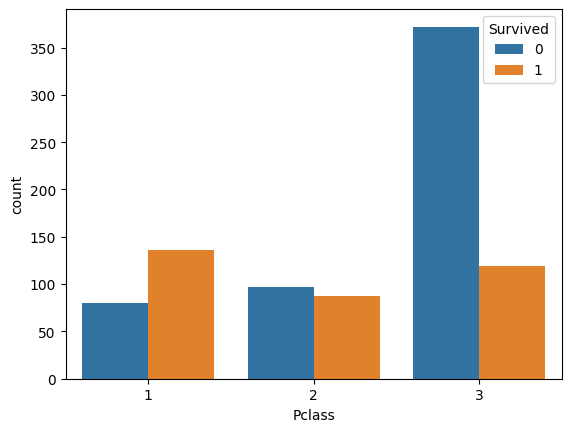

In [23]:
sns.countplot(x='Pclass', data=df, hue='Survived')

In [24]:
df[(df['Survived'] == 1) & (df['Pclass'] == 3)].shape[0]

119

<h3>📊 Custom Bar Graph Function (Survival Analysis)</h3>

This function compares how a feature behaves for passengers who survived vs who did not survive.

In [25]:
import seaborn as sns
import pandas as pd
def bar_graph(feature):
  Survived = df[df['Survived']==1][feature].value_counts()
  Dead = df[df['Survived']==0][feature].value_counts()

  new_df = pd.DataFrame([Survived,Dead])
  new_df.index = ['Survived','Dead']
  new_df.plot(kind='bar')


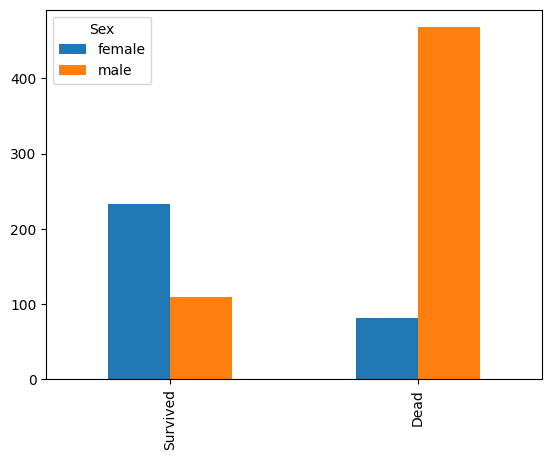

In [26]:
bar_graph('Sex')

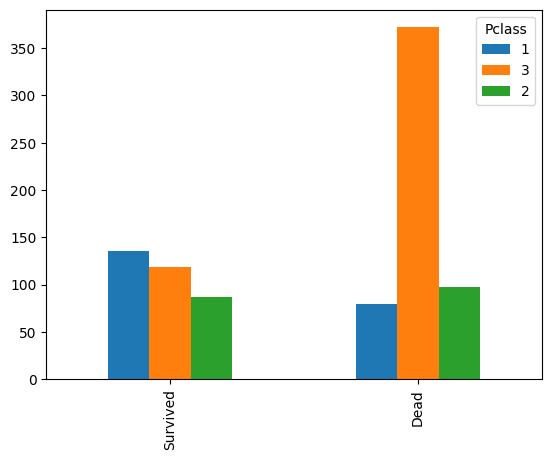

In [27]:
bar_graph('Pclass')

In [28]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,S


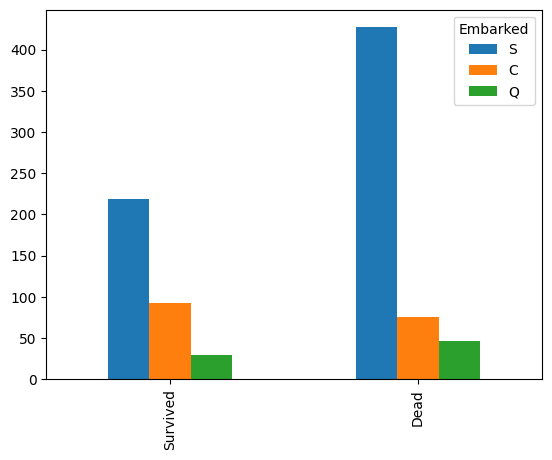

In [29]:
bar_graph('Embarked')

In [30]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

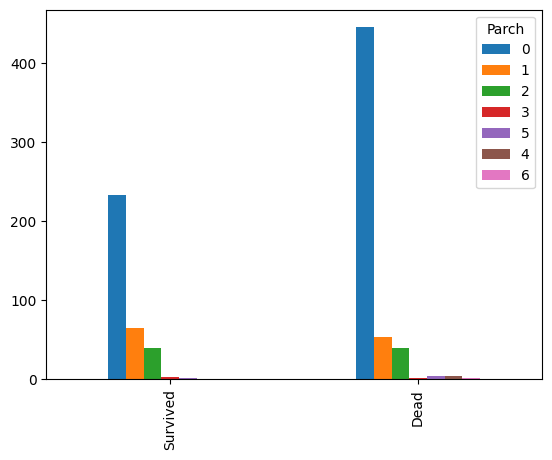

In [31]:
bar_graph('Parch')

<h3>📊 Automatic EDA Report (ydata_profiling)</h3>

This code generates a complete Exploratory Data Analysis (EDA) report of the dataset automatically.

In [32]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)

profile.to_file("Profile_Report_titanic.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 405.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<h3>🧠 Feature Engineering: Extracting Title from Name</h3>

This step is used to create a new feature called Title (Mr, Mrs, Miss, etc.) from the Name column.

In [33]:
train_data = [df]
for dataset in train_data:
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)

In [34]:
dataset['Title'].head()

0      Mr
1     Mrs
2    Miss
3     Mrs
4      Mr
Name: Title, dtype: object

In [35]:
dataset['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [36]:
df.drop(columns='Name',inplace=True)

In [37]:
df.head(20)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,0,3,male,22.000000,1,0,A/5 21171,7.2500,0,S,Mr
1,1,1,female,38.000000,1,0,PC 17599,71.2833,C85,C,Mrs
2,1,3,female,26.000000,0,0,STON/O2. 3101282,7.9250,0,S,Miss
3,1,1,female,35.000000,1,0,113803,53.1000,C123,S,Mrs
4,0,3,male,35.000000,0,0,373450,8.0500,0,S,Mr
5,0,3,male,29.699118,0,0,330877,8.4583,0,Q,Mr
6,0,1,male,54.000000,0,0,17463,51.8625,E46,S,Mr
7,0,3,male,2.000000,3,1,349909,21.0750,0,S,Master
8,1,3,female,27.000000,0,2,347742,11.1333,0,S,Mrs
9,1,2,female,14.000000,1,0,237736,30.0708,0,C,Mrs


<h3>🎫 Feature Engineering: Splitting Ticket into Number & Category</h3>

This step is used to break the Ticket column into two useful features: ticket number and ticket category.

In [38]:
df['Ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['Ticket_num'] = pd.to_numeric(df['Ticket_num'],
                                 errors='coerce',
                                 downcast='integer')


df['Ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['Ticket_cat'] = np.where(df['Ticket_cat'].str.isdigit(),
                            np.nan,
                            df['Ticket_cat']
                            )

In [39]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_num,Ticket_cat
0,0,3,male,22.0,1,0,A/5 21171,7.2500,0,S,Mr,21171.0,A/5
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,17599.0,PC
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,0,S,Miss,3101282.0,STON/O2.
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,Mrs,113803.0,NaN
4,0,3,male,35.0,0,0,373450,8.0500,0,S,Mr,373450.0,NaN


In [40]:
df['Ticket_cat'].fillna(0,inplace=True)

C:\Users\LENOVO THINKBOOK\AppData\Local\Temp\ipykernel_20652\88424809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ticket_cat'].fillna(0,inplace=True)


In [41]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin         0
Embarked      0
Title         0
Ticket_num    4
Ticket_cat    0
dtype: int64

In [42]:
df.drop(columns='Ticket',inplace=True)

In [43]:
df['Family'] = df['SibSp'] + df['Parch'] + 1

In [44]:
df['Family'].value_counts()

Family
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [45]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,Ticket_num,Ticket_cat,Family
0,0,3,male,22.000000,1,0,7.2500,0,S,Mr,21171.0,A/5,2
1,1,1,female,38.000000,1,0,71.2833,C85,C,Mrs,17599.0,PC,2
2,1,3,female,26.000000,0,0,7.9250,0,S,Miss,3101282.0,STON/O2.,1
3,1,1,female,35.000000,1,0,53.1000,C123,S,Mrs,113803.0,0,2
4,0,3,male,35.000000,0,0,8.0500,0,S,Mr,373450.0,0,1
5,0,3,male,29.699118,0,0,8.4583,0,Q,Mr,330877.0,0,1
6,0,1,male,54.000000,0,0,51.8625,E46,S,Mr,17463.0,0,1
7,0,3,male,2.000000,3,1,21.0750,0,S,Master,349909.0,0,5
8,1,3,female,27.000000,0,2,11.1333,0,S,Mrs,347742.0,0,3
9,1,2,female,14.000000,1,0,30.0708,0,C,Mrs,237736.0,0,2


In [46]:
df.shape

(891, 13)

<h3> Feature Engineering: Encoding Gender Column</h3>

This step converts the Sex (categorical) column into numerical values so that machine learning models can understand it.

In [47]:
sex_maping = {'male':0,'female':1}

for dataset in train_data:
    dataset['Sex'] = dataset['Sex'].map(sex_maping)

In [48]:
dataset['Sex']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64

In [49]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,Ticket_num,Ticket_cat,Family
0,0,3,0,22.0,1,0,7.2500,0,S,Mr,21171.0,A/5,2
1,1,1,1,38.0,1,0,71.2833,C85,C,Mrs,17599.0,PC,2
2,1,3,1,26.0,0,0,7.9250,0,S,Miss,3101282.0,STON/O2.,1
3,1,1,1,35.0,1,0,53.1000,C123,S,Mrs,113803.0,0,2
4,0,3,0,35.0,0,0,8.0500,0,S,Mr,373450.0,0,1


<h3> Feature Engineering: Extracting Cabin Information</h3>


In [50]:

for dataset in train_data:
    dataset['Deck_Floor'] = dataset['Cabin'].str.extract('([A-Z])',expand=False)
    dataset['Cabin_Number'] = dataset['Cabin'].str.extract('([0-9]+)',expand=False)


In [51]:
dataset['Cabin_Number']

0      NaN
1       85
2      NaN
3      123
4      NaN
      ... 
886    NaN
887     42
888    NaN
889    148
890    NaN
Name: Cabin_Number, Length: 891, dtype: object

In [52]:
df['Deck_Floor'].fillna(0,inplace=True)

C:\Users\LENOVO THINKBOOK\AppData\Local\Temp\ipykernel_20652\2836269649.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Deck_Floor'].fillna(0,inplace=True)


<h3>Dropping Unnecessary Features (Feature Selection)</h3>



In [53]:
df.drop(['SibSp','Parch', 'Cabin', 'Title', 'Ticket_num', 'Ticket_cat', 'Deck_Floor', 'Cabin_Number'], axis=1, inplace=True)

df.drop(columns=['Embarked'],inplace=True)

In [54]:
df.head(10)

,Survived,Pclass,Sex,Age,Fare,Family
0,0,3,0,22.000000,7.2500,2
1,1,1,1,38.000000,71.2833,2
2,1,3,1,26.000000,7.9250,1
3,1,1,1,35.000000,53.1000,2
4,0,3,0,35.000000,8.0500,1
5,0,3,0,29.699118,8.4583,1
6,0,1,0,54.000000,51.8625,1
7,0,3,0,2.000000,21.0750,5
8,1,3,1,27.000000,11.1333,3
9,1,2,1,14.000000,30.0708,2


<h3>Importing Machine Learning Models & Evaluation Tools</h3>


<h3> Explanation</h3>
Machine Learning Models

KNeighborsClassifier → classification based on nearest neighbors

DecisionTreeClassifier → tree-based decision making

RandomForestClassifier → ensemble of multiple decision trees (strong model)

GaussianNB → Naive Bayes probabilistic model

SVC → Support Vector Machine (good for complex boundaries)

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)

from sklearn.metrics import accuracy_score

<h3> Splitting Data into Training and Testing Sets</h3>


<h3> Explanation</h3>
 Features and Target
X → input features (all columns except Survived)
y → target variable (Survived column)

test_size = 0.3 → 30% data for testing, 70% for training

 Random State
random_state=42
Ensures same split every time you run code
Helps in reproducibility

In [56]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived',axis=1)
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [57]:
X_train

,Pclass,Sex,Age,Fare,Family
445,1,0,4.000000,81.8583,3
650,3,0,29.699118,7.8958,1
172,3,1,1.000000,11.1333,3
450,2,0,36.000000,27.7500,4
314,2,0,43.000000,26.2500,3
...,...,...,...,...,...
106,3,1,21.000000,7.6500,1
270,1,0,29.699118,31.0000,1
860,3,0,41.000000,14.1083,3
435,1,1,14.000000,120.0000,4


# 1. KNN

In [58]:
clf = KNeighborsClassifier(n_neighbors= 14)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

score = cross_val_score(clf,X_train,y_train, cv=k_fold, n_jobs=1, scoring='accuracy')

In [59]:
round(np.mean(score*100),2)

np.float64(71.9)

In [60]:
from sklearn.model_selection import cross_val_score
import numpy as np

k_range = range(1, 31)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, cv=5).mean()
    scores.append(score)

best_k = k_range[np.argmax(scores)]
print("Best k:", best_k, "Score:", max(scores))

Best k: 16 Score: 0.7206967741935484


# 2. Decision Tree

In [61]:
clf = DecisionTreeClassifier()
scoring = 'accuracy'

score = cross_val_score(clf, X_train,y_train,cv=k_fold,n_jobs=1,scoring=scoring)
print(score)

[0.84126984 0.76190476 0.73015873 0.80645161 0.80645161 0.80645161
 0.90322581 0.87096774 0.74193548 0.74193548]


In [62]:
round(np.mean(score)*100,2)


np.float64(80.11)

# 3. Random Forest

In [63]:
clf = RandomForestClassifier()

k_range = (1,31)
scores = []

for k in k_range:
    clf = RandomForestClassifier(n_estimators=k)
    score = cross_val_score(clf,X_train,y_train,cv=k_fold,n_jobs=1,scoring='accuracy')
    scores.append(score)
    
print(np.max(scores))

0.9032258064516129


In [64]:
round(np.mean(score)*100,2)

np.float64(82.18)

# 4. Naive Bayes

In [65]:
clf = GaussianNB()

scoring='accuracy'
score = cross_val_score(clf,X_train,y_train,cv=k_fold,n_jobs=1,scoring=scoring)
score

array([0.82539683, 0.74603175, 0.76190476, 0.82258065, 0.74193548,
       0.80645161, 0.75806452, 0.83870968, 0.75806452, 0.85483871])

In [66]:
round(np.mean(score)*100,2)

np.float64(79.14)

# 5. SVM

In [67]:
clf = SVC()
scoring = 'accuracy'
score = cross_val_score(clf,X_train,y_train,cv=k_fold,n_jobs=1,scoring=scoring)
score

array([0.65079365, 0.6984127 , 0.66666667, 0.67741935, 0.64516129,
       0.64516129, 0.66129032, 0.66129032, 0.59677419, 0.75806452])

In [68]:
round(np.mean(score)*100,2)

np.float64(66.61)

<h2> Model Comparison (KNN, Decision Tree, Random Forest, Naive Bayes, SVM)</h2>



In [69]:
models = []

# 1. KNN
models.append(('KNN', KNeighborsClassifier()))

# 2. Decision Tree
models.append(('Decision Tree', DecisionTreeClassifier(random_state=0)))

# 3. Random Forest
models.append(('Random Forest', RandomForestClassifier(random_state=0)))

# 4. Naive Bayes
models.append(('Naive Bayes', GaussianNB()))

# 5. SVM
models.append(('SVM', SVC()))

results = []
names = []

for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=k_fold, scoring='accuracy')
    results.append(cv_results.mean())
    names.append(name)

leaderboard = pd.DataFrame({
    'Model': names,
    'Accuracy': results
})

leaderboard = leaderboard.sort_values(by='Accuracy', ascending=False)
leaderboard

,Model,Accuracy
2,Random Forest,0.820276
1,Decision Tree,0.794598
3,Naive Bayes,0.791398
0,KNN,0.698336
4,SVM,0.666103


In [70]:
df.to_csv('titanic_cleaned.csv',index=False)